In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import os
print(os.listdir('/kaggle/input/netflix-shows'))

['netflix_titles.csv']


In [10]:
df=pd.read_csv("/kaggle/input/netflix-shows/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [16]:
df.shape
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [19]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [21]:
df["director"]=df["director"].fillna("unknown")
df["cast"]=df["cast"].fillna("unknown")
df["country"]=df["country"].fillna("unknown")
df["date_added"]=df["date_added"].fillna("unknown")
df["rating"]=df["rating"].fillna("unknown")
df["duration"]=df["duration"].fillna("unknown")
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


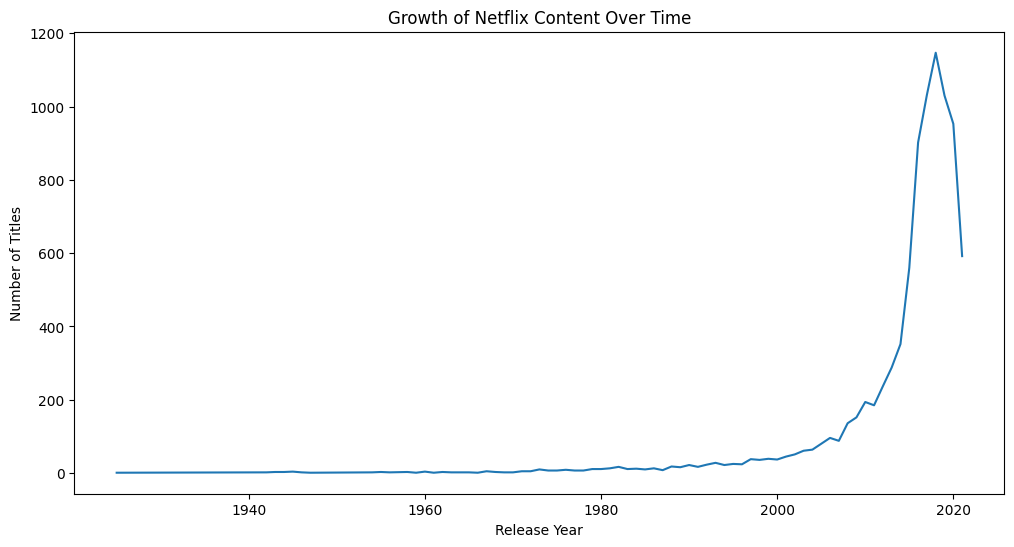

In [22]:
#storytelling
#netflix content growth over time
yearly_content=df.groupby('release_year').size()
plt.figure(figsize=(12,6))
plt.plot(yearly_content.index, yearly_content.values)
plt.title("Growth of Netflix Content Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()


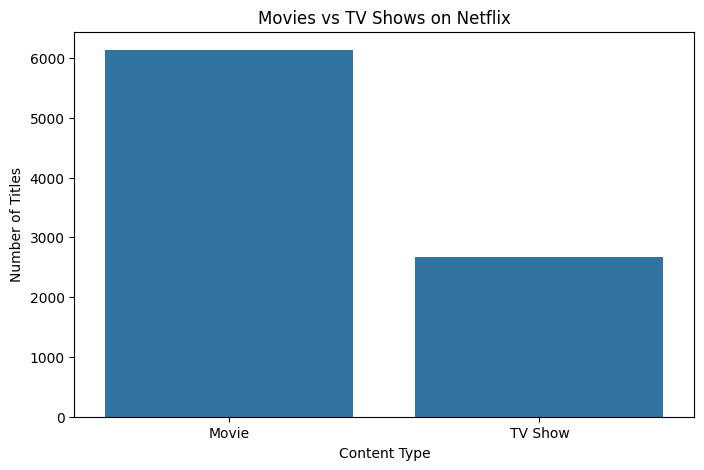

In [26]:
content_type=df['type'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(
    x=content_type.index,
    y=content_type.values
)
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

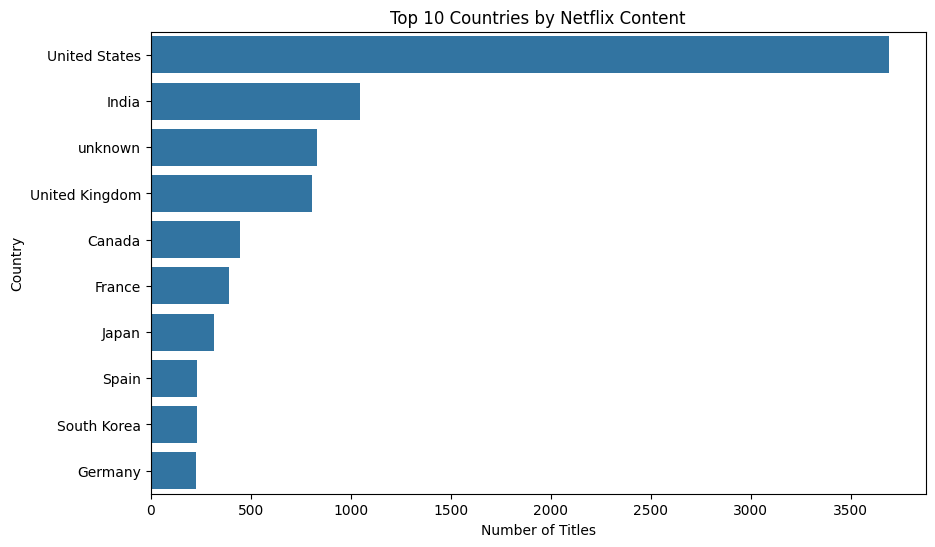

In [27]:
countries = df['country'].dropna().str.split(', ')
country_list = countries.explode()
country_counts = country_list.value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)
plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

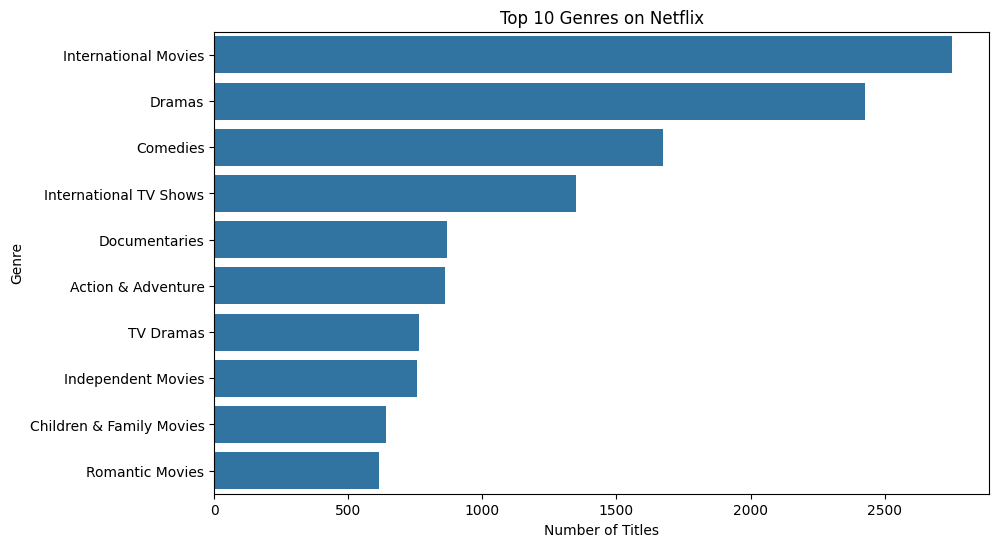

In [28]:
genres = df['listed_in'].dropna().str.split(', ')
genre_list = genres.explode()
genre_counts = genre_list.value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

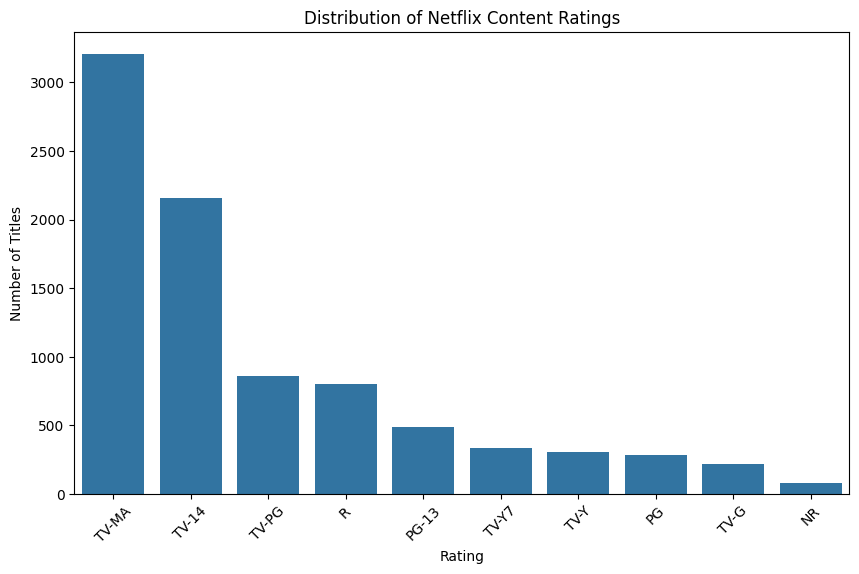

In [29]:
rating_counts = df['rating'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)
plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

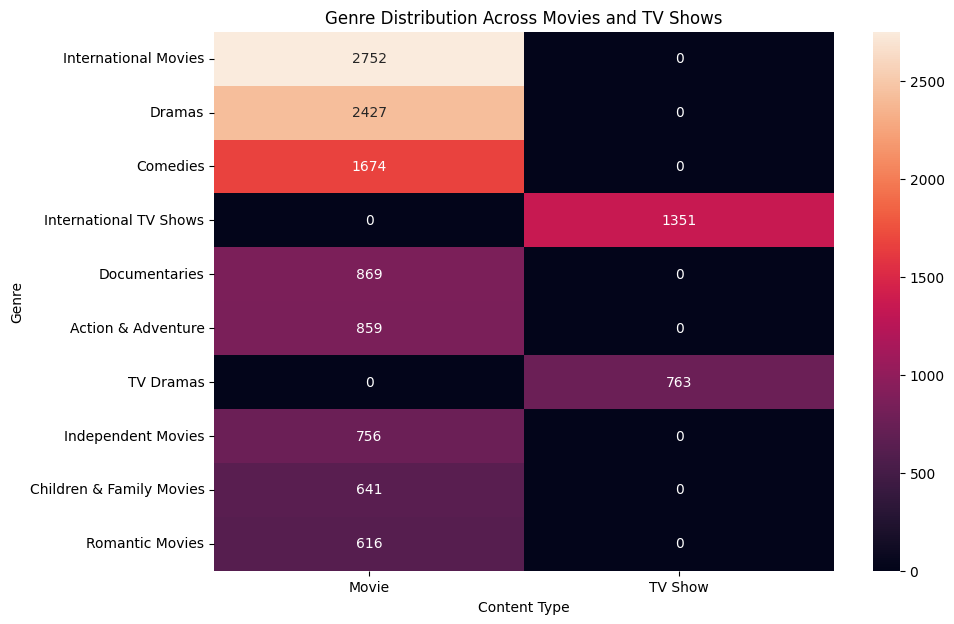

In [30]:
temp = df[['type', 'listed_in']].dropna().copy()
temp['genre'] = temp['listed_in'].str.split(', ')
temp = temp.explode('genre')
heatmap_data = pd.crosstab(
    temp['genre'],
    temp['type']
)
top_genres = heatmap_data.sum(axis=1).nlargest(10).index
heatmap_data = heatmap_data.loc[top_genres]
plt.figure(figsize=(10,7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d'
)
plt.title("Genre Distribution Across Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Genre")
plt.show()